# 🔬 Veri Madenciliği — 5. Ders: Kümeleme Analizi ve Anomali Tespiti
### Haydar Kılıç | Yapay Zeka Mühendisliği

Bu notebook, ders sunumundaki teorik içeriğin Python ile uygulamalı karşılığıdır.  
Her bölüm: **Teori → Kod → Görselleştirme → Yorum** düzeninde ilerler.

---


## 0. Kütüphane Kurulumları ve Genel Ayarlar

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.spatial.distance import cdist
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (silhouette_score, silhouette_samples,
                             pairwise_distances, confusion_matrix)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.stats import zscore

import warnings
warnings.filterwarnings("ignore")

# Görsel tema
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
PALETTE = ["#2196F3","#E91E63","#4CAF50","#FF9800","#9C27B0","#00BCD4"]
print("✅ Tüm kütüphaneler yüklendi.")


✅ Tüm kütüphaneler yüklendi.


---
## 1. Kümelemeye Giriş

> **Tanım:** Kümeleme analizi, etiket bilgisi olmaksızın veriyi anlamlı gruplara bölme işlemidir.  
> Aynı kümedeki noktalar birbirine yakın, farklı kümelerdeki noktalar birbirinden uzak olmalıdır.

Aşağıdaki örnekte, 3 doğal küme barındıran bir veri seti oluşturup görselleştiriyoruz.


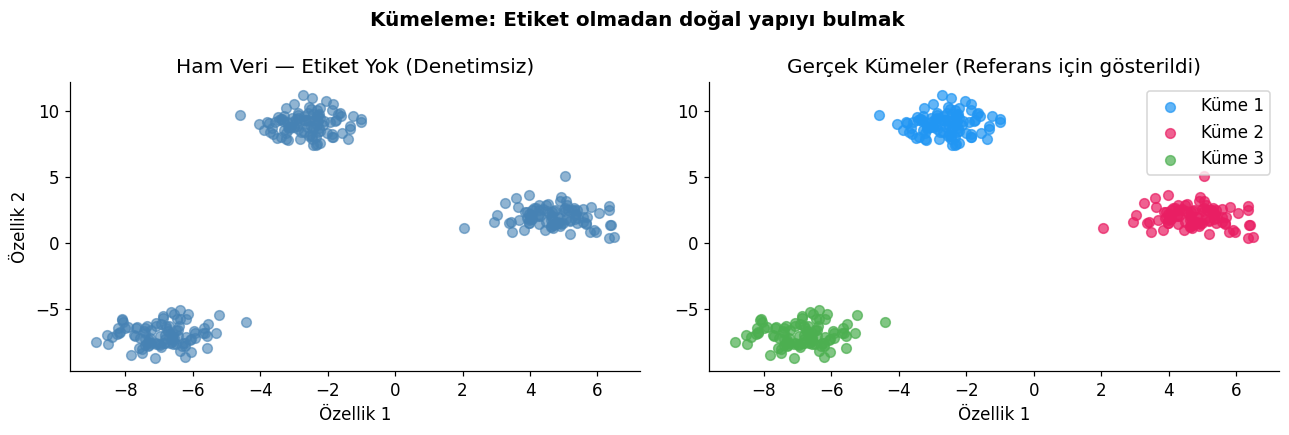

3 doğal küme içeren 300 noktalı veri seti oluşturuldu.


In [2]:
np.random.seed(42)
X_intro, y_intro = make_blobs(n_samples=300, centers=3,
                               cluster_std=0.8, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Sol: Etiketsiz (denetimsiz senaryo)
axes[0].scatter(X_intro[:, 0], X_intro[:, 1], c="steelblue", alpha=0.6, s=40)
axes[0].set_title("Ham Veri — Etiket Yok (Denetimsiz)")
axes[0].set_xlabel("Özellik 1"); axes[0].set_ylabel("Özellik 2")

# Sağ: Gerçek kümeler gösterimi
for k in range(3):
    mask = y_intro == k
    axes[1].scatter(X_intro[mask, 0], X_intro[mask, 1],
                    color=PALETTE[k], alpha=0.7, s=40, label=f"Küme {k+1}")
axes[1].set_title("Gerçek Kümeler (Referans için gösterildi)")
axes[1].legend(); axes[1].set_xlabel("Özellik 1")

plt.suptitle("Kümeleme: Etiket olmadan doğal yapıyı bulmak", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
print("3 doğal küme içeren 300 noktalı veri seti oluşturuldu.")


---
## 2. K-Means Algoritması

### 2.1 Temel Algoritma ve SSE

K-Means aşağıdaki adımları yakınsayana kadar tekrarlar:
1. K rastgele centroid seç
2. Her noktayı en yakın centroid'e ata
3. Centroid'leri küme ortalaması olarak güncelle

**Amaç fonksiyonu (SSE — Toplam Kare Hata):**

$$SSE = \sum_{i=1}^{K} \sum_{\mathbf{x} \in C_i} \|\mathbf{x} - c_i\|^2$$


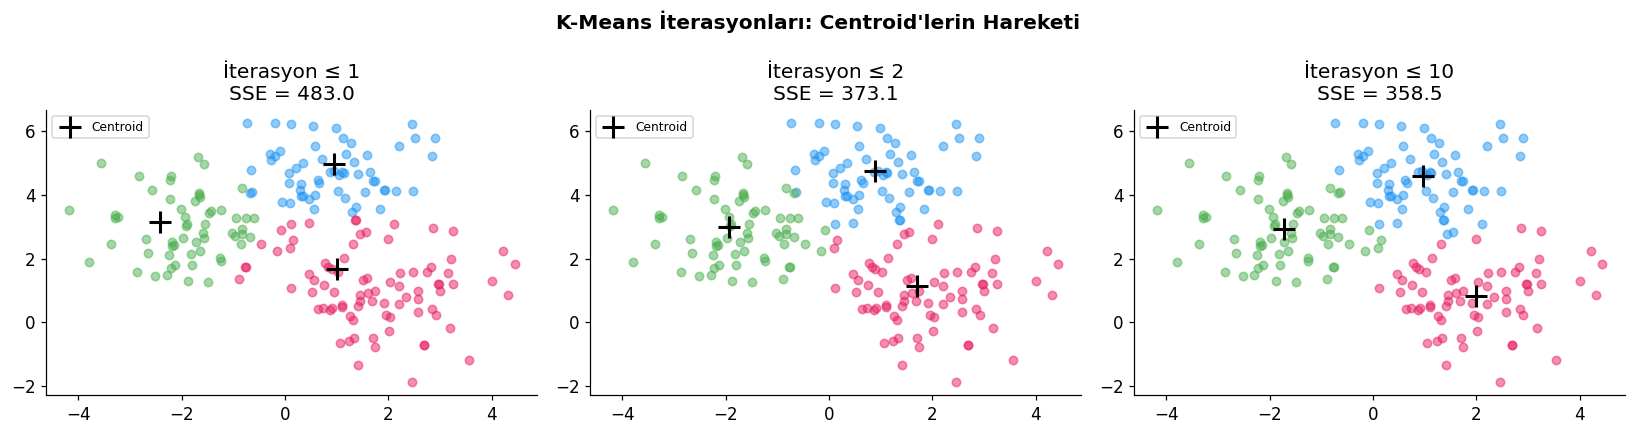

In [3]:
# ── K-Means adım adım görselleştirilmesi ──────────────────────────────────
np.random.seed(0)
X_km, _ = make_blobs(n_samples=200, centers=3, cluster_std=1.0, random_state=0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors_iter = [PALETTE[0], PALETTE[1], PALETTE[2]]

for ax_idx, n_iter in enumerate([1, 2, 10]):
    km = KMeans(n_clusters=3, max_iter=n_iter, n_init=1,
                init="random", random_state=42)
    km.fit(X_km)
    labels = km.labels_
    centroids = km.cluster_centers_

    ax = axes[ax_idx]
    for k in range(3):
        mask = labels == k
        ax.scatter(X_km[mask, 0], X_km[mask, 1],
                   color=colors_iter[k], alpha=0.5, s=30)
    ax.scatter(centroids[:, 0], centroids[:, 1],
               c="black", marker="+", s=200, linewidths=2, zorder=5, label="Centroid")
    sse = km.inertia_
    ax.set_title(f"İterasyon ≤ {n_iter}\nSSE = {sse:.1f}")
    ax.legend(fontsize=8)

plt.suptitle("K-Means İterasyonları: Centroid'lerin Hareketi", fontweight="bold")
plt.tight_layout()
plt.show()


### 2.2 Başlangıç Merkezi Seçimi: Rastgele vs K-Means++

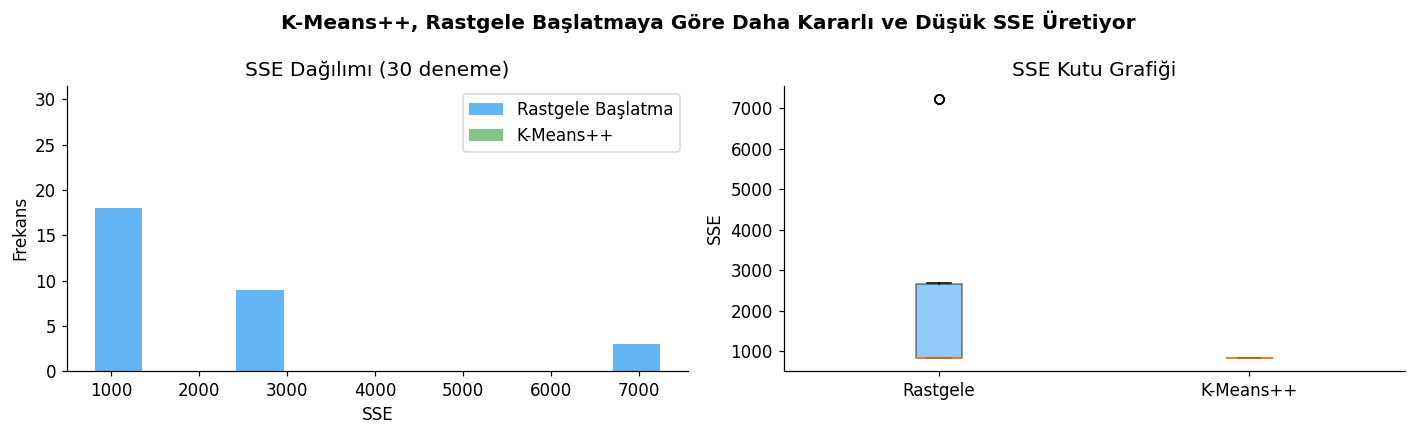

Rastgele — Ort. SSE: 2016.9 ± 1924.7
K-Means++ — Ort. SSE: 822.7    ± 0.0


In [4]:
# Rastgele başlatma vs K-Means++ karşılaştırması
np.random.seed(7)
X_init, _ = make_blobs(n_samples=300, centers=4, cluster_std=1.2, random_state=7)

sse_random, sse_pp = [], []
TRIALS = 30

for seed in range(TRIALS):
    km_rand = KMeans(n_clusters=4, init="random", n_init=1, random_state=seed)
    km_rand.fit(X_init)
    sse_random.append(km_rand.inertia_)

    km_pp = KMeans(n_clusters=4, init="k-means++", n_init=1, random_state=seed)
    km_pp.fit(X_init)
    sse_pp.append(km_pp.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(sse_random, bins=12, color=PALETTE[0], alpha=0.7, label="Rastgele Başlatma")
axes[0].hist(sse_pp,    bins=12, color=PALETTE[2], alpha=0.7, label="K-Means++")
axes[0].set_xlabel("SSE"); axes[0].set_ylabel("Frekans")
axes[0].set_title("SSE Dağılımı (30 deneme)")
axes[0].legend()

axes[1].boxplot([sse_random, sse_pp], labels=["Rastgele", "K-Means++"],
                patch_artist=True,
                boxprops=dict(facecolor=PALETTE[0], alpha=0.5))
axes[1].set_ylabel("SSE"); axes[1].set_title("SSE Kutu Grafiği")

plt.suptitle("K-Means++, Rastgele Başlatmaya Göre Daha Kararlı ve Düşük SSE Üretiyor",
             fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Rastgele — Ort. SSE: {np.mean(sse_random):.1f} ± {np.std(sse_random):.1f}")
print(f"K-Means++ — Ort. SSE: {np.mean(sse_pp):.1f}    ± {np.std(sse_pp):.1f}")


### 2.3 Optimal K Seçimi: SSE Dirsek + Silhouette

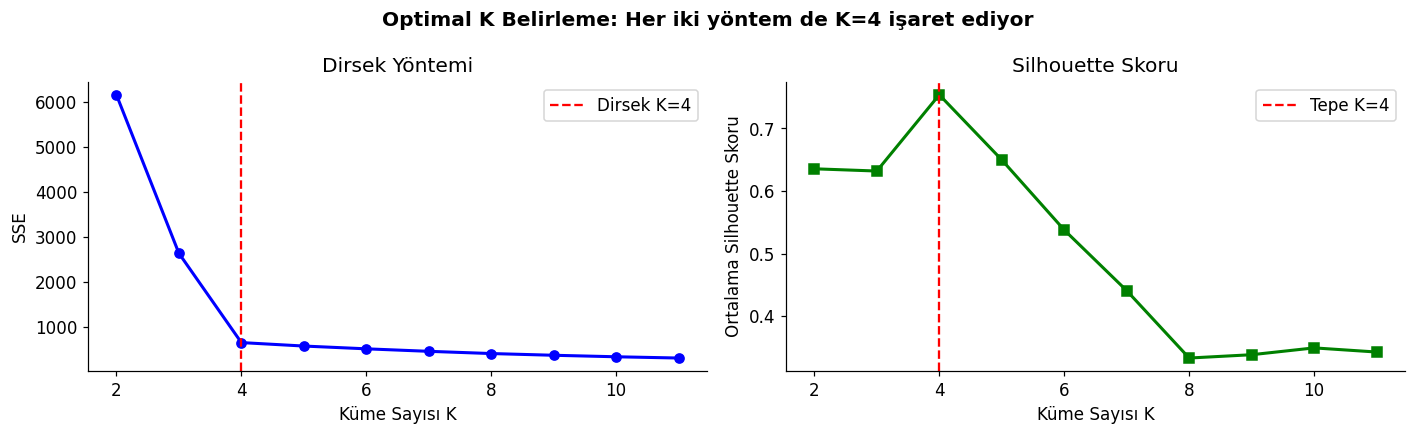

In [5]:
X_opt, _ = make_blobs(n_samples=400, centers=4, cluster_std=0.9, random_state=3)

k_range = range(2, 12)
sse_list, sil_list = [], []

for k in k_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels = km.fit_predict(X_opt)
    sse_list.append(km.inertia_)
    sil_list.append(silhouette_score(X_opt, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(list(k_range), sse_list, "bo-", linewidth=2)
axes[0].axvline(4, color="red", linestyle="--", label="Dirsek K=4")
axes[0].set_xlabel("Küme Sayısı K"); axes[0].set_ylabel("SSE")
axes[0].set_title("Dirsek Yöntemi"); axes[0].legend()

axes[1].plot(list(k_range), sil_list, "gs-", linewidth=2)
opt_k = list(k_range)[np.argmax(sil_list)]
axes[1].axvline(opt_k, color="red", linestyle="--", label=f"Tepe K={opt_k}")
axes[1].set_xlabel("Küme Sayısı K"); axes[1].set_ylabel("Ortalama Silhouette Skoru")
axes[1].set_title("Silhouette Skoru"); axes[1].legend()

plt.suptitle("Optimal K Belirleme: Her iki yöntem de K=4 işaret ediyor",
             fontweight="bold")
plt.tight_layout()
plt.show()


### 2.4 Silhouette Analizi — Nokta Bazında İnceleme

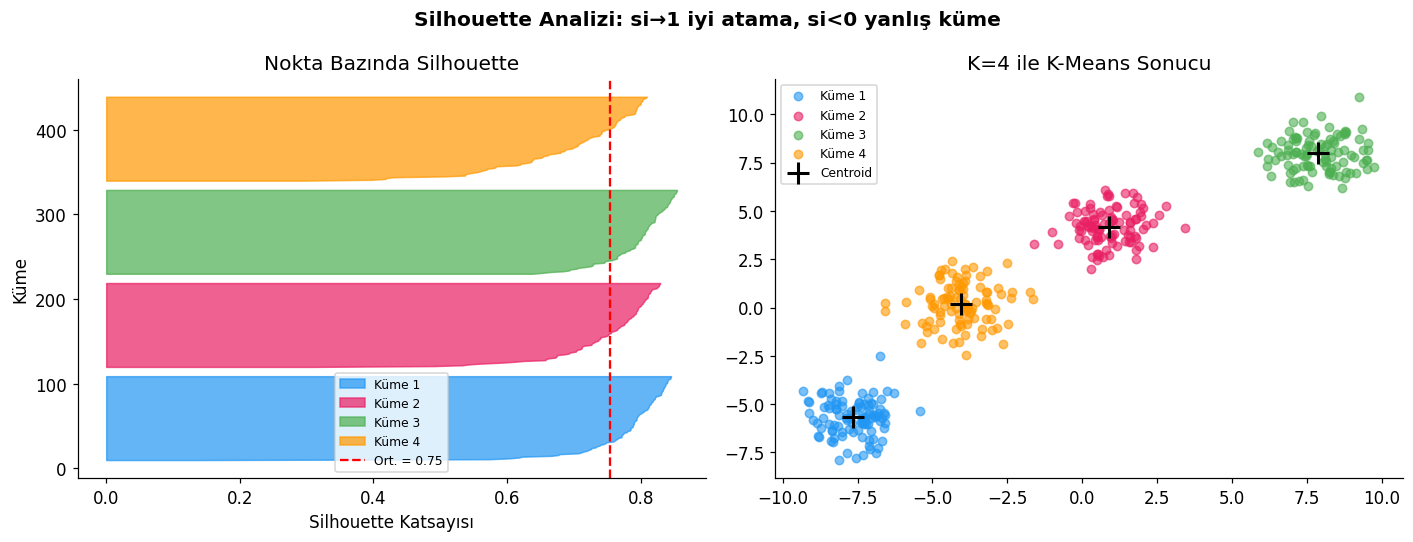

Ortalama Silhouette Skoru: 0.754


In [6]:
K_BEST = 4
km_best = KMeans(n_clusters=K_BEST, init="k-means++", n_init=10, random_state=42)
labels_best = km_best.fit_predict(X_opt)
sil_vals = silhouette_samples(X_opt, labels_best)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
y_lower = 10

for k in range(K_BEST):
    vals_k = np.sort(sil_vals[labels_best == k])
    size_k = vals_k.shape[0]
    y_upper = y_lower + size_k
    axes[0].fill_betweenx(np.arange(y_lower, y_upper), 0, vals_k,
                          alpha=0.7, color=PALETTE[k], label=f"Küme {k+1}")
    y_lower = y_upper + 10

axes[0].axvline(np.mean(sil_vals), color="red", linestyle="--",
                label=f"Ort. = {np.mean(sil_vals):.2f}")
axes[0].set_xlabel("Silhouette Katsayısı"); axes[0].set_ylabel("Küme")
axes[0].set_title("Nokta Bazında Silhouette"); axes[0].legend(fontsize=8)

for k in range(K_BEST):
    mask = labels_best == k
    axes[1].scatter(X_opt[mask, 0], X_opt[mask, 1],
                    color=PALETTE[k], alpha=0.6, s=30, label=f"Küme {k+1}")
axes[1].scatter(km_best.cluster_centers_[:, 0], km_best.cluster_centers_[:, 1],
                c="black", marker="+", s=200, linewidths=2, zorder=5, label="Centroid")
axes[1].set_title("K=4 ile K-Means Sonucu"); axes[1].legend(fontsize=8)

plt.suptitle("Silhouette Analizi: si→1 iyi atama, si<0 yanlış küme", fontweight="bold")
plt.tight_layout()
plt.show()
print(f"Ortalama Silhouette Skoru: {np.mean(sil_vals):.3f}")


### 2.5 K-Means'ın Sınırlılıkları: Küresel Olmayan Kümeler

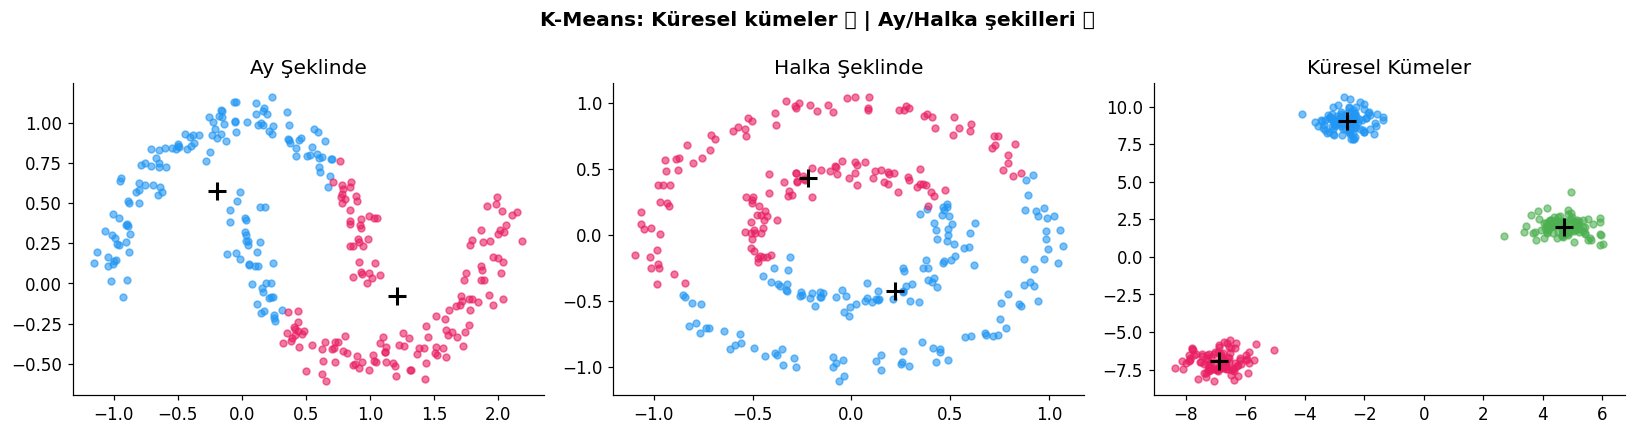

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
datasets = {
    "Ay Şeklinde": make_moons(n_samples=300, noise=0.07, random_state=42),
    "Halka Şeklinde": make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42),
    "Küresel Kümeler": make_blobs(n_samples=300, centers=3, cluster_std=0.6, random_state=42),
}

for ax, (title, (X_d, _)) in zip(axes, datasets.items()):
    km_d = KMeans(n_clusters=2 if "Küresel" not in title else 3,
                  n_init=10, random_state=42)
    labels_d = km_d.fit_predict(X_d)
    for k in np.unique(labels_d):
        mask = labels_d == k
        ax.scatter(X_d[mask, 0], X_d[mask, 1], color=PALETTE[k], alpha=0.6, s=20)
    ax.scatter(km_d.cluster_centers_[:, 0], km_d.cluster_centers_[:, 1],
               c="black", marker="+", s=150, linewidths=2)
    ax.set_title(title)

plt.suptitle("K-Means: Küresel kümeler ✅ | Ay/Halka şekilleri ❌", fontweight="bold")
plt.tight_layout()
plt.show()


---
## 3. Hiyerarşik Kümeleme (Aglomeratif)

Hiyerarşik kümeleme, iç içe geçmiş kümelerin ağaç yapısını (dendrogram) oluşturur.  
K sayısını önceden belirtmeye gerek yoktur; dendrogram yatay çizgiyle kesilerek istenilen K elde edilir.

**Bağlantı yöntemleri:**  
- `single` → MIN (tek bağlantı) — zincirleme etkisi riski  
- `complete` → MAX (tam bağlantı) — kompakt kümeler  
- `average` → UPGMA — dengeli  
- `ward` → SSE artışını minimize eder, genellikle en iyi sonuç


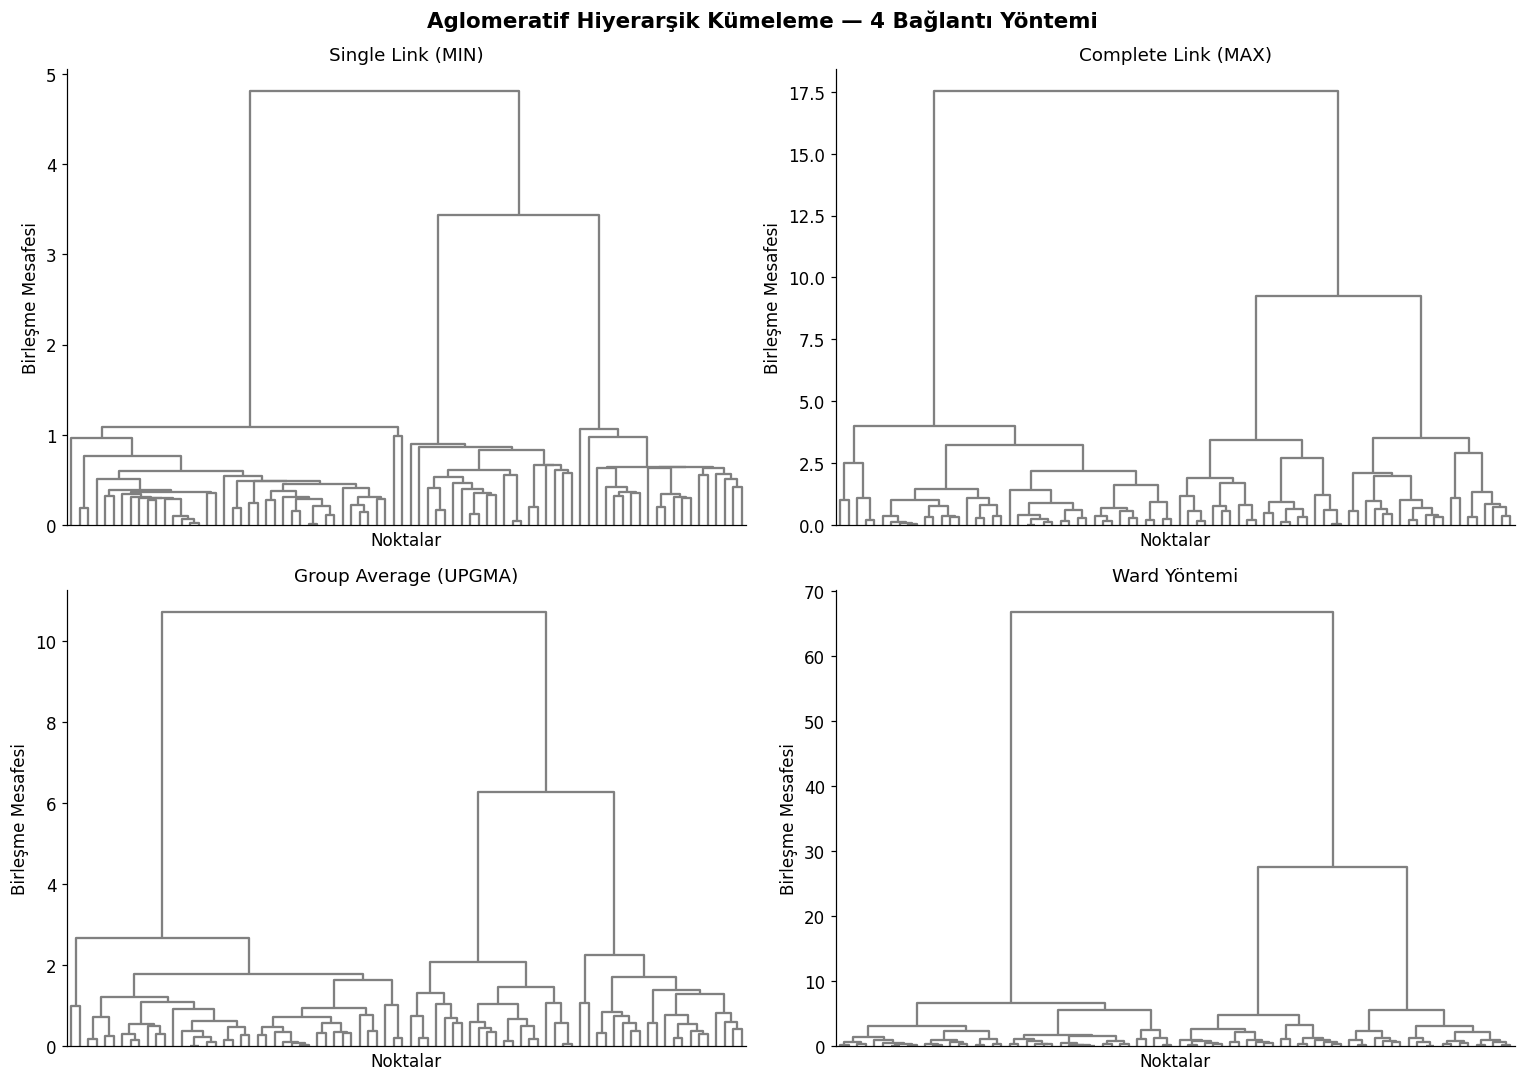

In [8]:
np.random.seed(5)
X_hier, y_hier = make_blobs(n_samples=80, centers=4,
                             cluster_std=0.8, random_state=5)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
methods = ["single", "complete", "average", "ward"]
titles  = ["Single Link (MIN)", "Complete Link (MAX)",
           "Group Average (UPGMA)", "Ward Yöntemi"]

for ax, method, title in zip(axes.ravel(), methods, titles):
    Z = linkage(X_hier, method=method)
    dendrogram(Z, ax=ax, color_threshold=0, above_threshold_color="grey",
               no_labels=True)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Noktalar"); ax.set_ylabel("Birleşme Mesafesi")

plt.suptitle("Aglomeratif Hiyerarşik Kümeleme — 4 Bağlantı Yöntemi", fontsize=14,
             fontweight="bold")
plt.tight_layout()
plt.show()


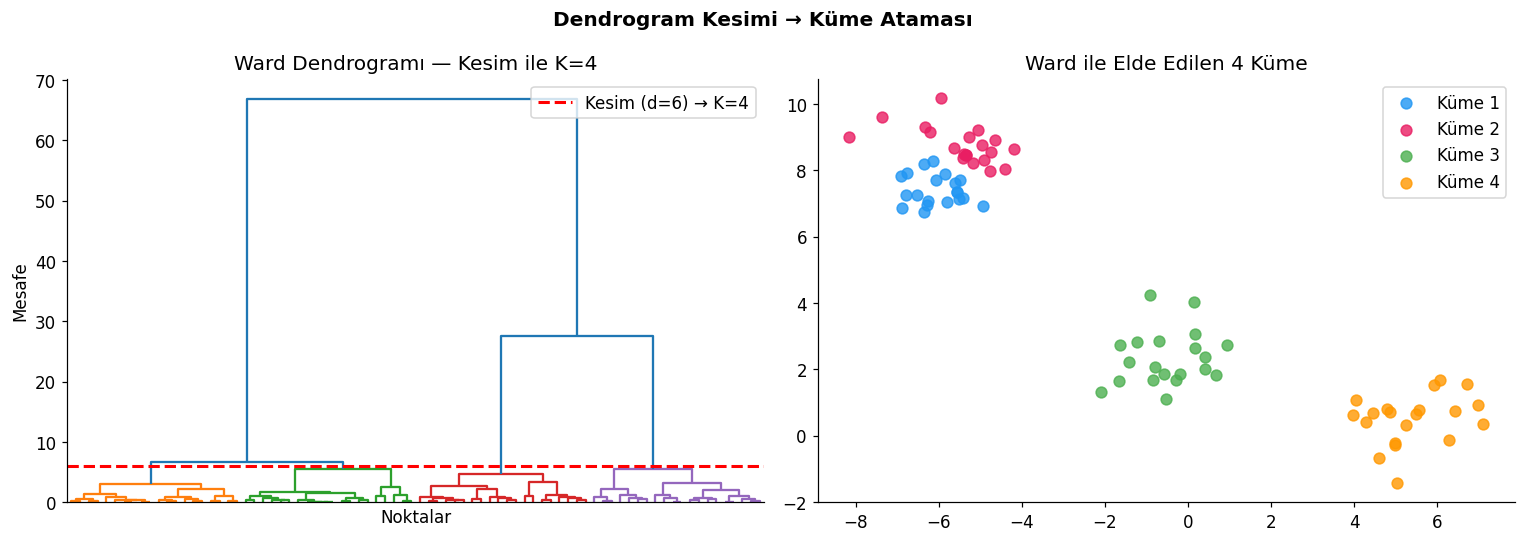

Ward — Silhouette Skoru: 0.574


In [9]:
# Ward dendrogramını keserek 4 küme elde etmek
Z_ward = linkage(X_hier, method="ward")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Dendrogram + kesim çizgisi
dn = dendrogram(Z_ward, ax=axes[0], color_threshold=6, no_labels=True)
axes[0].axhline(y=6, color="red", linestyle="--", linewidth=2, label="Kesim (d=6) → K=4")
axes[0].set_title("Ward Dendrogramı — Kesim ile K=4")
axes[0].legend(); axes[0].set_xlabel("Noktalar"); axes[0].set_ylabel("Mesafe")

# Küme ataması
labels_hier = fcluster(Z_ward, t=4, criterion="maxclust") - 1
for k in range(4):
    mask = labels_hier == k
    axes[1].scatter(X_hier[mask, 0], X_hier[mask, 1],
                    color=PALETTE[k], s=50, alpha=0.8, label=f"Küme {k+1}")
axes[1].set_title("Ward ile Elde Edilen 4 Küme")
axes[1].legend()

plt.suptitle("Dendrogram Kesimi → Küme Ataması", fontweight="bold")
plt.tight_layout()
plt.show()

sil_hier = silhouette_score(X_hier, labels_hier)
print(f"Ward — Silhouette Skoru: {sil_hier:.3f}")


---
## 4. DBSCAN — Yoğunluk Tabanlı Kümeleme

DBSCAN iki parametre kullanır:
- **ε (eps):** Komşuluk yarıçapı
- **MinPts:** Çekirdek sayılmak için gereken minimum komşu sayısı

Her nokta üç kategoriden birine girer:
- **Çekirdek:** ε içinde ≥ MinPts komşusu var
- **Sınır:** Çekirdek değil ama bir çekirdeğin ε komşuluğunda
- **Gürültü:** Ne çekirdek ne sınır


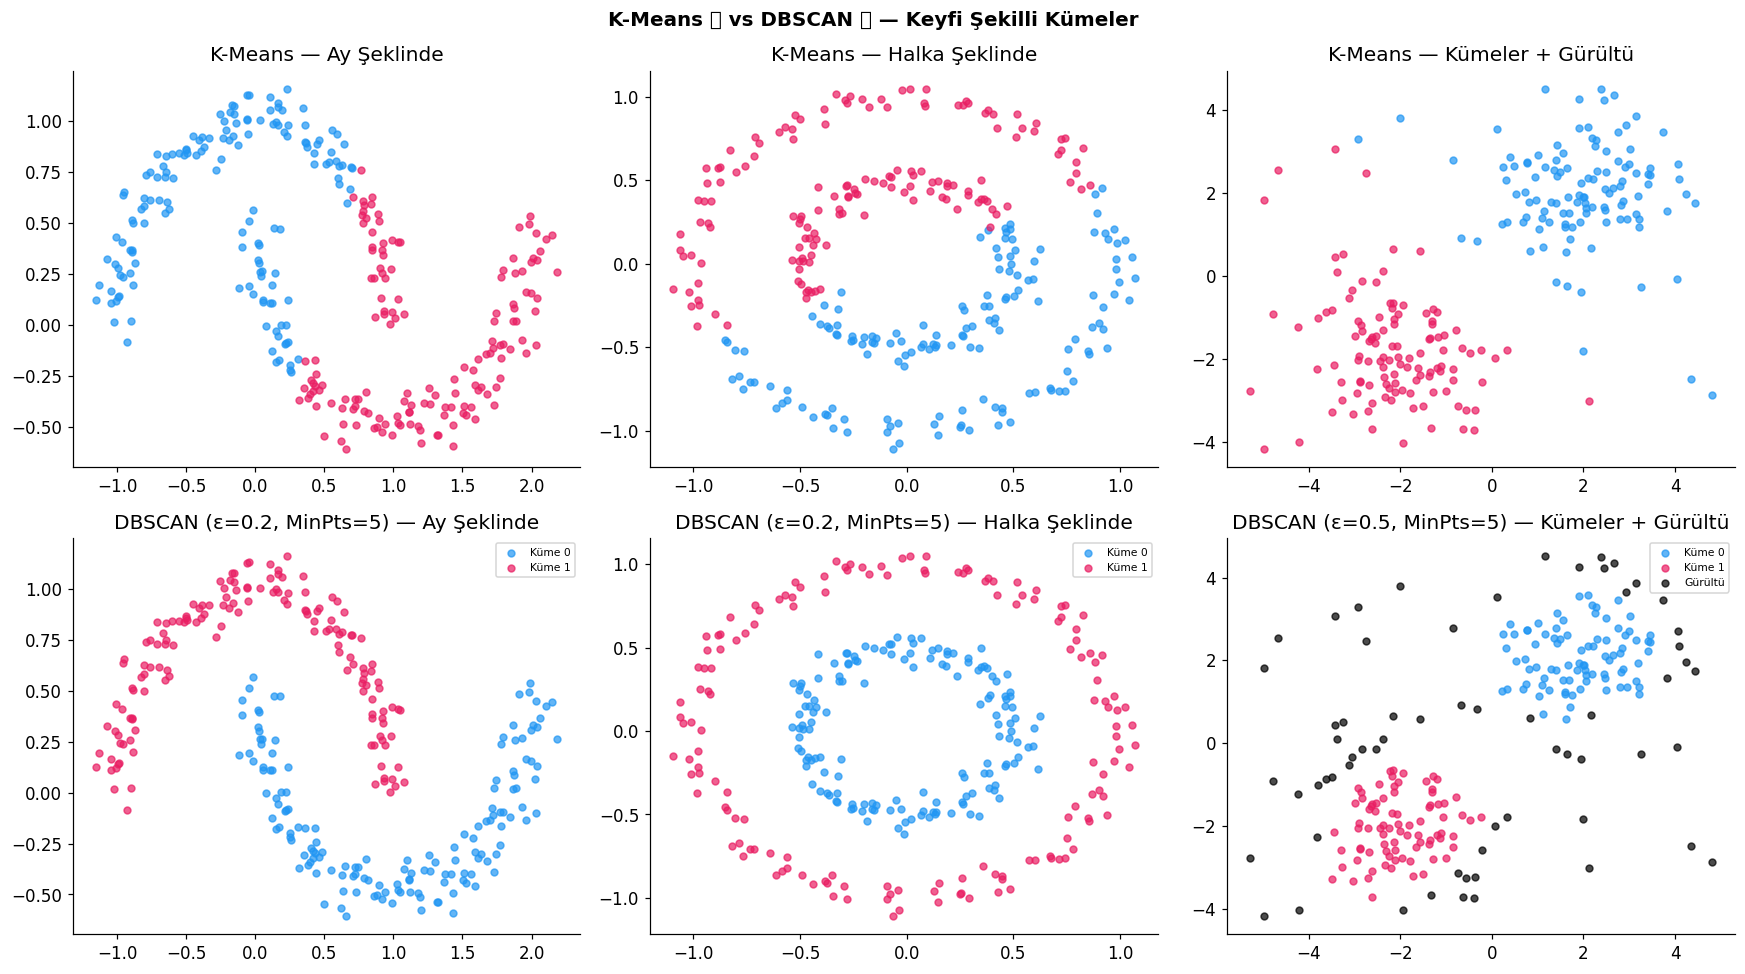

In [10]:
# DBSCAN — K-Means'ın başarısız olduğu şekillerde karşılaştırma
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

datasets_db = [
    ("Ay Şeklinde", make_moons(n_samples=300, noise=0.07, random_state=42)),
    ("Halka Şeklinde", make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42)),
    ("Kümeler + Gürültü", (np.vstack([
        np.random.randn(100, 2) + [2, 2],
        np.random.randn(100, 2) + [-2, -2],
        np.random.uniform(-5, 5, (30, 2))   # gürültü
    ]), None)),
]
params = [(0.2, 5), (0.2, 5), (0.5, 5)]

for col, ((title, (X_d, _)), (eps, mpts)) in enumerate(zip(datasets_db, params)):
    # K-Means
    km_d = KMeans(n_clusters=2, n_init=10, random_state=42)
    lkm = km_d.fit_predict(X_d)
    for k in np.unique(lkm):
        axes[0][col].scatter(X_d[lkm==k, 0], X_d[lkm==k, 1],
                             color=PALETTE[k], s=20, alpha=0.7)
    axes[0][col].set_title(f"K-Means — {title}")

    # DBSCAN
    db = DBSCAN(eps=eps, min_samples=mpts)
    ldb = db.fit_predict(X_d)
    unique_labels = set(ldb)
    color_map = {lbl: (PALETTE[i % len(PALETTE)] if lbl != -1 else "black")
                 for i, lbl in enumerate(unique_labels)}
    for lbl in unique_labels:
        mask = ldb == lbl
        label_str = f"Küme {lbl}" if lbl != -1 else "Gürültü"
        axes[1][col].scatter(X_d[mask, 0], X_d[mask, 1],
                             color=color_map[lbl], s=20, alpha=0.7, label=label_str)
    axes[1][col].set_title(f"DBSCAN (ε={eps}, MinPts={mpts}) — {title}")
    axes[1][col].legend(fontsize=7)

plt.suptitle("K-Means ❌ vs DBSCAN ✅ — Keyfi Şekilli Kümeler", fontsize=13,
             fontweight="bold")
plt.tight_layout()
plt.show()


### 4.1 ε Seçimi — k-dist Grafiği

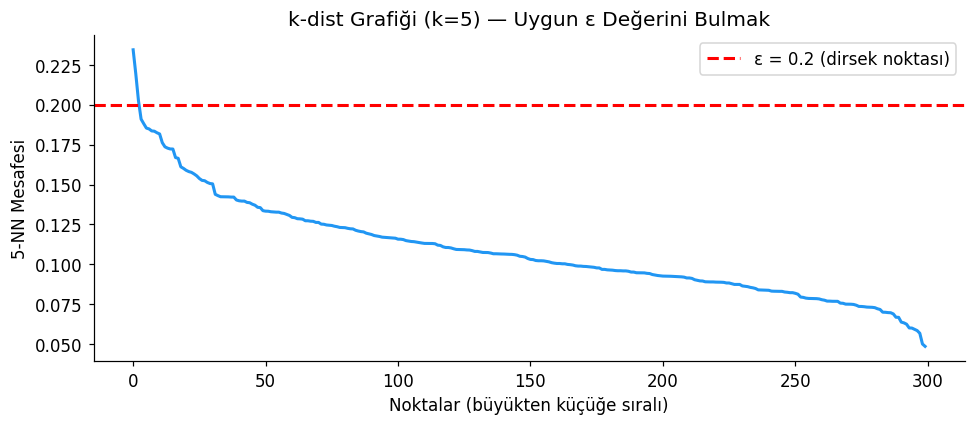

Dirsek noktasındaki ε değeri yaklaşık 0.20 olarak belirlendi.


In [11]:
X_moon, _ = make_moons(n_samples=300, noise=0.07, random_state=42)
k_nn = 5

nbrs = NearestNeighbors(n_neighbors=k_nn + 1).fit(X_moon)
distances, _ = nbrs.kneighbors(X_moon)
k_distances = np.sort(distances[:, k_nn])[::-1]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_distances, color=PALETTE[0], linewidth=2)
ax.axhline(y=0.2, color="red", linestyle="--", linewidth=2,
           label="ε = 0.2 (dirsek noktası)")
ax.set_xlabel("Noktalar (büyükten küçüğe sıralı)")
ax.set_ylabel(f"{k_nn}-NN Mesafesi")
ax.set_title(f"k-dist Grafiği (k={k_nn}) — Uygun ε Değerini Bulmak")
ax.legend()
plt.tight_layout()
plt.show()
print("Dirsek noktasındaki ε değeri yaklaşık 0.20 olarak belirlendi.")


### 4.2 ε ve MinPts'in Etkisi

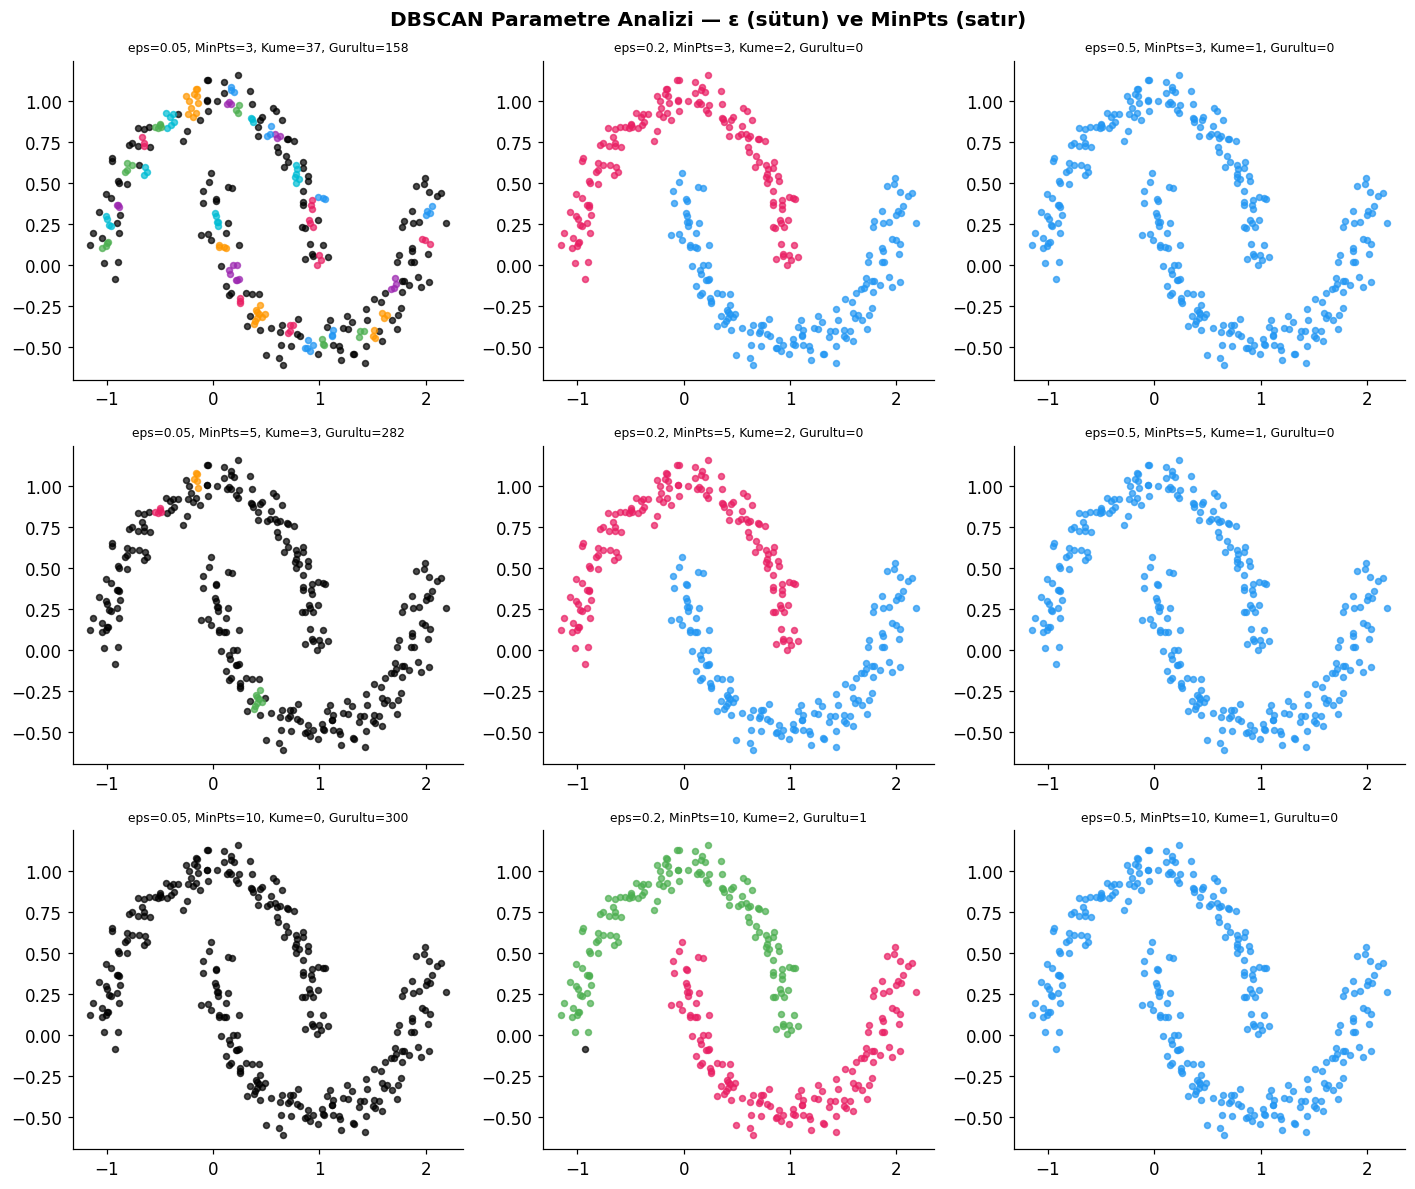

In [12]:
X_db_test, _ = make_moons(n_samples=300, noise=0.07, random_state=42)

eps_vals  = [0.05, 0.2, 0.5]
mpts_vals = [3, 5, 10]

fig, axes = plt.subplots(3, 3, figsize=(13, 11))

for r, mpts in enumerate(mpts_vals):
    for c, eps in enumerate(eps_vals):
        db = DBSCAN(eps=eps, min_samples=mpts)
        ldb = db.fit_predict(X_db_test)
        n_clusters = len(set(ldb)) - (1 if -1 in ldb else 0)
        n_noise    = np.sum(ldb == -1)
        ax = axes[r][c]
        unique = set(ldb)
        for i, lbl in enumerate(sorted(unique)):
            mask = ldb == lbl
            col  = "black" if lbl == -1 else PALETTE[i % len(PALETTE)]
            ax.scatter(X_db_test[mask, 0], X_db_test[mask, 1],
                       c=col, s=15, alpha=0.7)
        title_str = "eps={}, MinPts={}, Kume={}, Gurultu={}".format(eps, mpts, n_clusters, n_noise)
        ax.set_title(title_str, fontsize=8)


plt.suptitle("DBSCAN Parametre Analizi — ε (sütun) ve MinPts (satır)", fontweight="bold")
plt.tight_layout()
plt.show()


---
## 5. Küme Değerlendirmesi

### 5.1 Denetimsiz (İç) Değerlendirme — SSE ve Silhouette

Silhouette katsayısı her nokta için:
$$s_i = \frac{b_i - a_i}{\max(a_i, b_i)} \in [-1, 1]$$

- $a_i$: kendi kümesindeki noktalara ortalama mesafe (küçük → iyi)  
- $b_i$: en yakın komşu kümedeki noktalara ortalama mesafe (büyük → iyi)


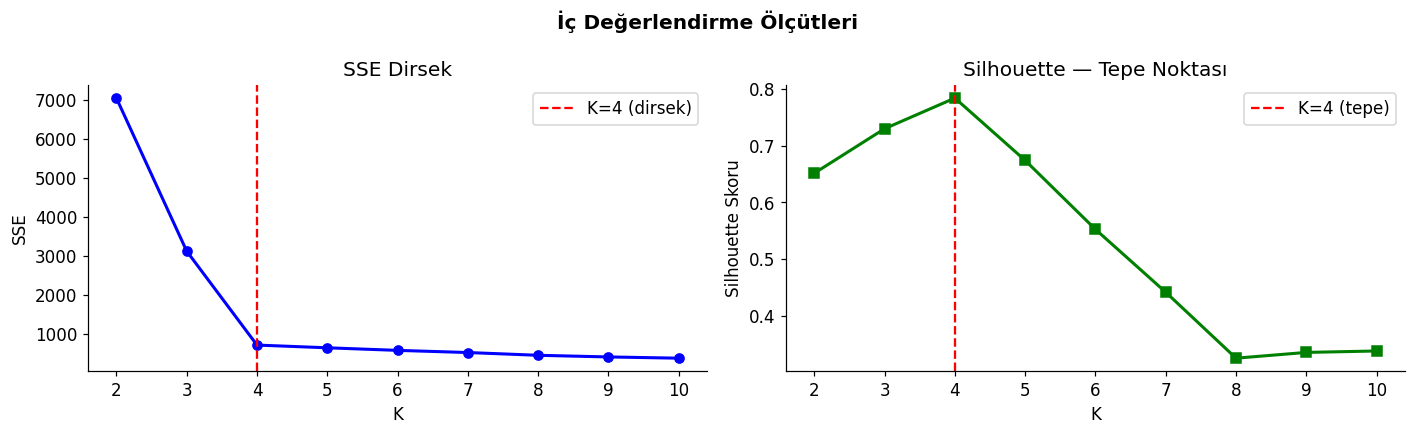

En iyi K (Silhouette): 4
En yüksek Silhouette : 0.784


In [13]:
X_eval, y_eval = make_blobs(n_samples=400, centers=4, cluster_std=1.0, random_state=10)
k_list = list(range(2, 11))
sse_e, sil_e = [], []

for k in k_list:
    km_e = KMeans(n_clusters=k, n_init=10, random_state=42)
    lbl  = km_e.fit_predict(X_eval)
    sse_e.append(km_e.inertia_)
    sil_e.append(silhouette_score(X_eval, lbl))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(k_list, sse_e, "bo-", linewidth=2)
axes[0].axvline(4, color="red", linestyle="--", label="K=4 (dirsek)")
axes[0].set_xlabel("K"); axes[0].set_ylabel("SSE"); axes[0].set_title("SSE Dirsek")
axes[0].legend()

axes[1].plot(k_list, sil_e, "gs-", linewidth=2)
axes[1].axvline(4, color="red", linestyle="--", label="K=4 (tepe)")
axes[1].set_xlabel("K"); axes[1].set_ylabel("Silhouette Skoru")
axes[1].set_title("Silhouette — Tepe Noktası"); axes[1].legend()

plt.suptitle("İç Değerlendirme Ölçütleri", fontweight="bold")
plt.tight_layout()
plt.show()
print(f"En iyi K (Silhouette): {k_list[np.argmax(sil_e)]}")
print(f"En yüksek Silhouette : {max(sil_e):.3f}")


### 5.2 Denetimli (Dış) Değerlendirme — Saflık ve Entropi

Oluşum Matrisi (satır=gerçek sınıf, sütun=tahmin edilen küme):
         Küme 0  Küme 1  Küme 2  Küme 3
Sınıf 0      69       0       0       6
Sınıf 1       0       0      75       0
Sınıf 2       2       0       0      73
Sınıf 3       0      75       0       0

Saflık (Purity)     : 0.973
Entropi (Ağırlıklı) : 0.146


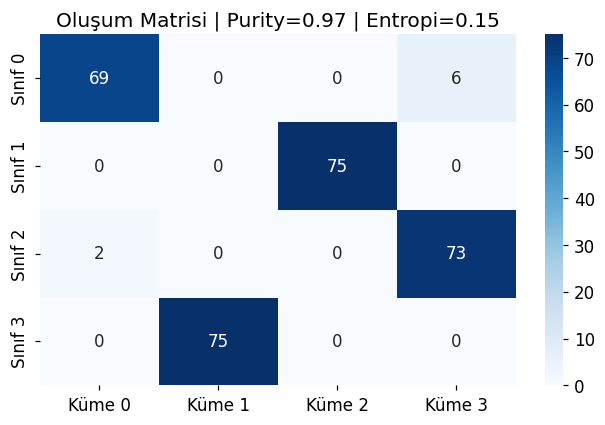

In [14]:
from sklearn.metrics.cluster import contingency_matrix

X_sup, y_sup = make_blobs(n_samples=300, centers=4, cluster_std=1.0, random_state=99)
km_sup = KMeans(n_clusters=4, n_init=10, random_state=42)
pred   = km_sup.fit_predict(X_sup)

ct = contingency_matrix(y_sup, pred)
print("Oluşum Matrisi (satır=gerçek sınıf, sütun=tahmin edilen küme):")
print(pd.DataFrame(ct, index=[f"Sınıf {i}" for i in range(4)],
                   columns=[f"Küme {j}" for j in range(4)]))
print()

# Saflık
purity = np.sum(np.max(ct, axis=0)) / np.sum(ct)
print(f"Saflık (Purity)     : {purity:.3f}")

# Entropi (ağırlıklı ortalama)
total = np.sum(ct)
entropy_total = 0
for j in range(ct.shape[1]):
    col  = ct[:, j]
    n_j  = np.sum(col)
    if n_j == 0: continue
    p    = col / n_j
    p    = p[p > 0]
    entropy_j = -np.sum(p * np.log2(p))
    entropy_total += (n_j / total) * entropy_j
print(f"Entropi (Ağırlıklı) : {entropy_total:.3f}")

# Görsel
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=[f"Küme {j}" for j in range(4)],
            yticklabels=[f"Sınıf {i}" for i in range(4)])
ax.set_title(f"Oluşum Matrisi | Purity={purity:.2f} | Entropi={entropy_total:.2f}")
plt.tight_layout()
plt.show()


---
## 6. Anomali Tespiti

> **Anomali:** Normal örneklerin oluşturduğu dağılımla uyuşmayan; o dağılım altında olası olmayan gözlemdir.

Temel senaryo:
- **Gürültü** → veri kalitesi sorunu; elemek istiyoruz  
- **Gerçek anomali** → nadir ama gerçek olay; tespit etmek istiyoruz


### 6.1 İstatistiksel Yaklaşım — z-Skoru ve Gaussian

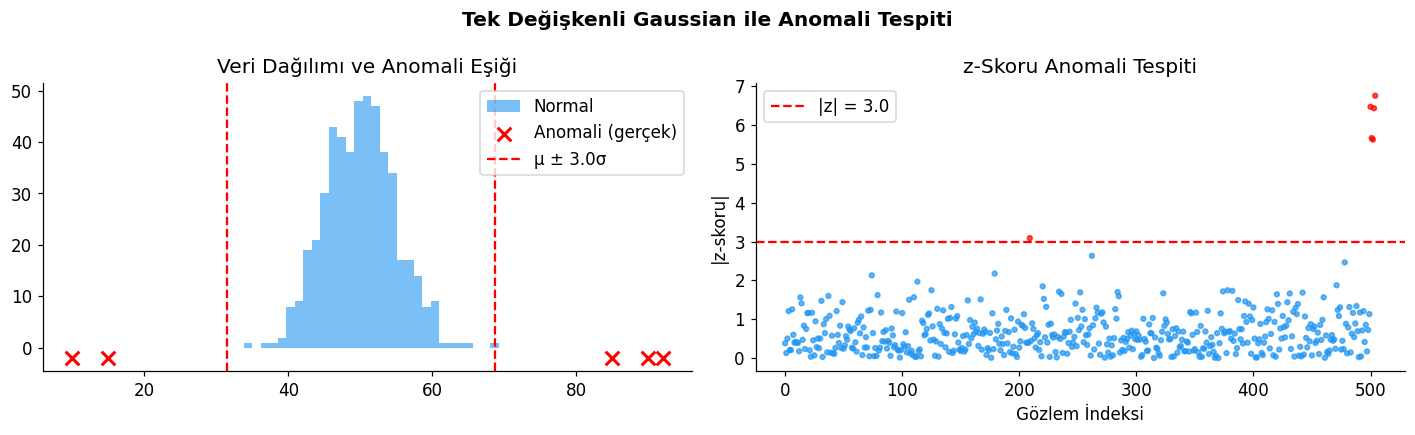

Tespit edilen anomali sayısı: 6
Tespit edilen değerler: [69.3 10.  15.  85.  90.  92. ]


In [15]:
np.random.seed(42)
normal_data = np.random.normal(loc=50, scale=5, size=500)
anomalies   = np.array([10, 15, 85, 90, 92])
data_all    = np.concatenate([normal_data, anomalies])

mu, sigma = data_all.mean(), data_all.std()
z_scores  = np.abs(zscore(data_all))
threshold = 3.0
detected  = data_all[z_scores >= threshold]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Dağılım + anomaliler
axes[0].hist(normal_data, bins=30, color=PALETTE[0], alpha=0.6, label="Normal")
axes[0].scatter(anomalies, np.zeros_like(anomalies) - 2, color="red",
                s=80, marker="x", linewidths=2, label="Anomali (gerçek)")
axes[0].axvline(mu + threshold * sigma, color="red", linestyle="--",
                label=f"μ ± {threshold}σ")
axes[0].axvline(mu - threshold * sigma, color="red", linestyle="--")
axes[0].set_title("Veri Dağılımı ve Anomali Eşiği")
axes[0].legend()

# z-skor grafiği
axes[1].scatter(range(len(data_all)), z_scores, c=["red" if z >= threshold else PALETTE[0]
                for z in z_scores], s=10, alpha=0.7)
axes[1].axhline(threshold, color="red", linestyle="--", label=f"|z| = {threshold}")
axes[1].set_xlabel("Gözlem İndeksi"); axes[1].set_ylabel("|z-skoru|")
axes[1].set_title("z-Skoru Anomali Tespiti"); axes[1].legend()

plt.suptitle("Tek Değişkenli Gaussian ile Anomali Tespiti", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Tespit edilen anomali sayısı: {len(detected)}")
print(f"Tespit edilen değerler: {np.round(detected, 1)}")


### 6.2 Mahalanobis Mesafesi — Çok Değişkenli Anomali

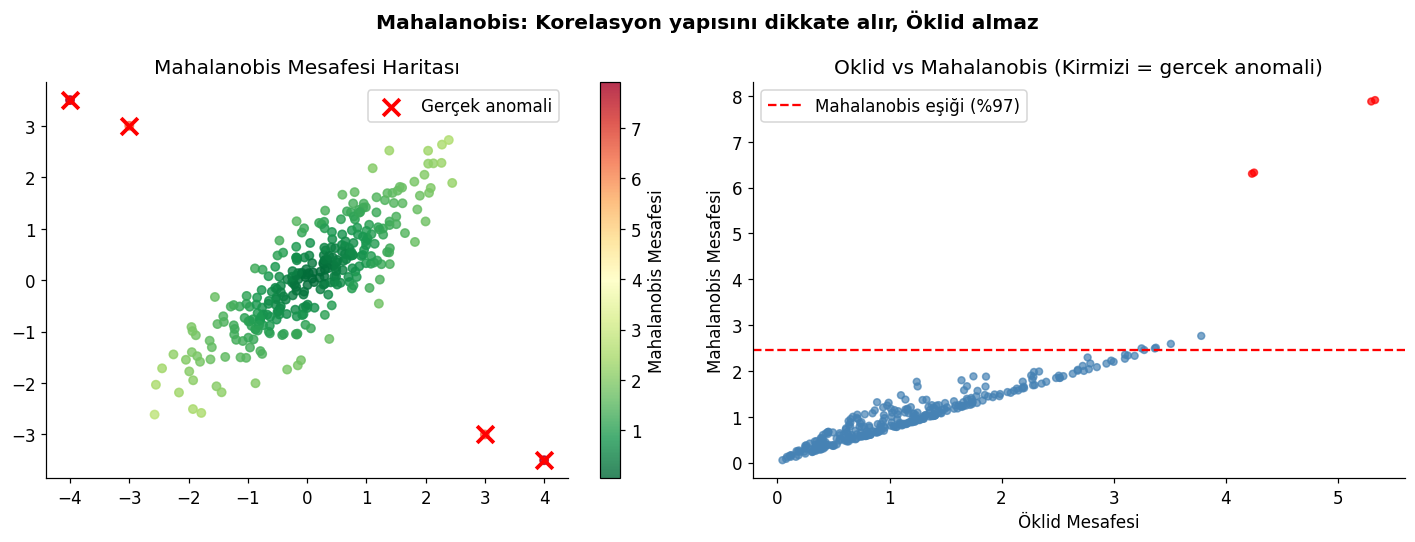

In [16]:
np.random.seed(0)
# Korelasyonlu normal veri
cov = [[1, 0.85], [0.85, 1]]
X_mah = np.random.multivariate_normal([0, 0], cov, 300)
# Anomaliler: korelasyon örüntüsünü bozanlar
anom_pts = np.array([[-3, 3], [3, -3], [-4, 3.5], [4, -3.5]])
X_all    = np.vstack([X_mah, anom_pts])

mu_mah = X_all.mean(axis=0)
S_inv  = np.linalg.inv(np.cov(X_all.T))

def mahalanobis(x, mu, S_inv):
    diff = x - mu
    return np.sqrt(diff @ S_inv @ diff.T)

mah_dists = np.array([mahalanobis(pt, mu_mah, S_inv) for pt in X_all])
euc_dists = np.linalg.norm(X_all - mu_mah, axis=1)
mah_thresh = np.percentile(mah_dists, 97)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter: renk = Mahalanobis mesafesi
sc = axes[0].scatter(X_all[:, 0], X_all[:, 1], c=mah_dists,
                     cmap="RdYlGn_r", s=30, alpha=0.8)
axes[0].scatter(anom_pts[:, 0], anom_pts[:, 1], c="red", marker="x",
                s=120, linewidths=2.5, label="Gerçek anomali", zorder=5)
plt.colorbar(sc, ax=axes[0], label="Mahalanobis Mesafesi")
axes[0].set_title("Mahalanobis Mesafesi Haritası")
axes[0].legend()

# Öklid vs Mahalanobis karşılaştırması
axes[1].scatter(euc_dists, mah_dists, c=["red" if i >= len(X_mah)
               else "steelblue" for i in range(len(X_all))], s=20, alpha=0.7)
axes[1].axhline(mah_thresh, color="red", linestyle="--",
                label=f"Mahalanobis eşiği (%97)")
axes[1].set_xlabel("Öklid Mesafesi"); axes[1].set_ylabel("Mahalanobis Mesafesi")
axes[1].set_title("Oklid vs Mahalanobis (Kirmizi = gercek anomali)")

axes[1].legend()

plt.suptitle("Mahalanobis: Korelasyon yapısını dikkate alır, Öklid almaz", fontweight="bold")
plt.tight_layout()
plt.show()


### 6.3 LOF — Yerel Aykırı Değer Faktörü

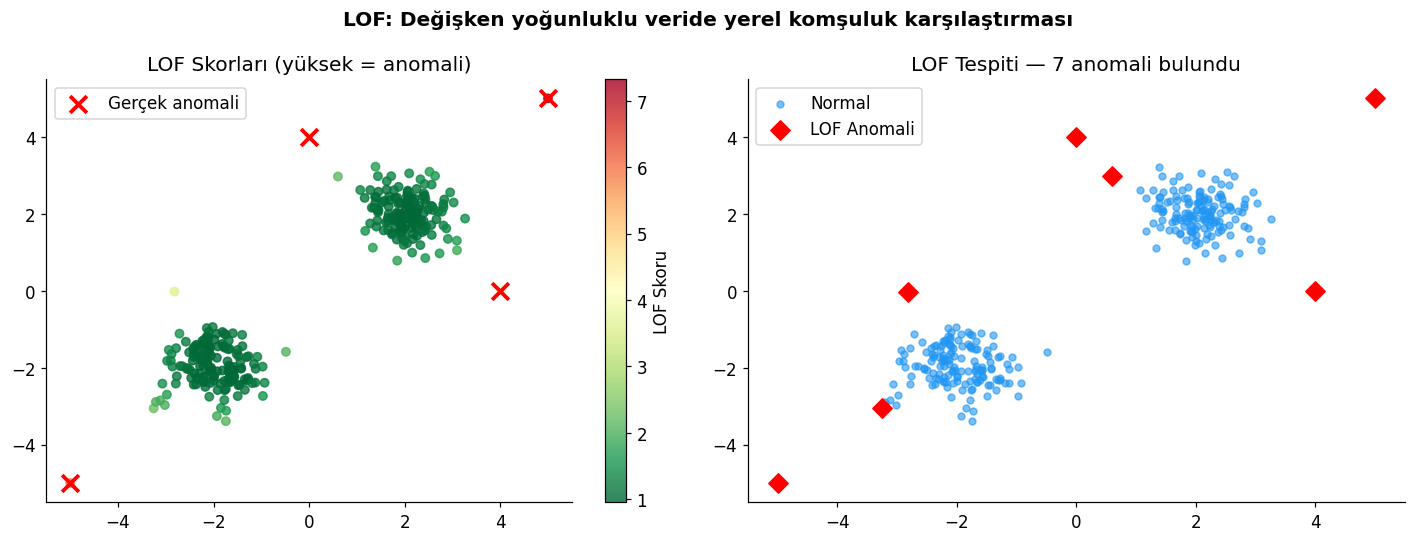

In [17]:
np.random.seed(1)
X_lof_a = np.random.randn(150, 2) * 0.5 + [2, 2]
X_lof_b = np.random.randn(150, 2) * 0.5 + [-2, -2]
X_anom  = np.array([[5, 5], [-5, -5], [0, 4], [4, 0]])
X_lof   = np.vstack([X_lof_a, X_lof_b, X_anom])

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.02)
y_lof = lof.fit_predict(X_lof)          # -1: anomali, 1: normal
scores = -lof.negative_outlier_factor_   # büyük → anomali

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sc = axes[0].scatter(X_lof[:, 0], X_lof[:, 1], c=scores,
                     cmap="RdYlGn_r", s=30, alpha=0.8)
plt.colorbar(sc, ax=axes[0], label="LOF Skoru")
axes[0].scatter(X_anom[:, 0], X_anom[:, 1], c="red", marker="x",
                s=120, linewidths=2.5, zorder=5, label="Gerçek anomali")
axes[0].set_title("LOF Skorları (yüksek = anomali)"); axes[0].legend()

normal_mask = y_lof == 1
anom_mask   = y_lof == -1
axes[1].scatter(X_lof[normal_mask, 0], X_lof[normal_mask, 1],
                color=PALETTE[0], s=20, alpha=0.6, label="Normal")
axes[1].scatter(X_lof[anom_mask, 0], X_lof[anom_mask, 1],
                color="red", s=80, marker="D", label="LOF Anomali")
axes[1].set_title(f"LOF Tespiti — {anom_mask.sum()} anomali bulundu")
axes[1].legend()

plt.suptitle("LOF: Değişken yoğunluklu veride yerel komşuluk karşılaştırması",
             fontweight="bold")
plt.tight_layout()
plt.show()


### 6.4 PCA Tabanlı Yeniden Yapılandırma ile Anomali Tespiti

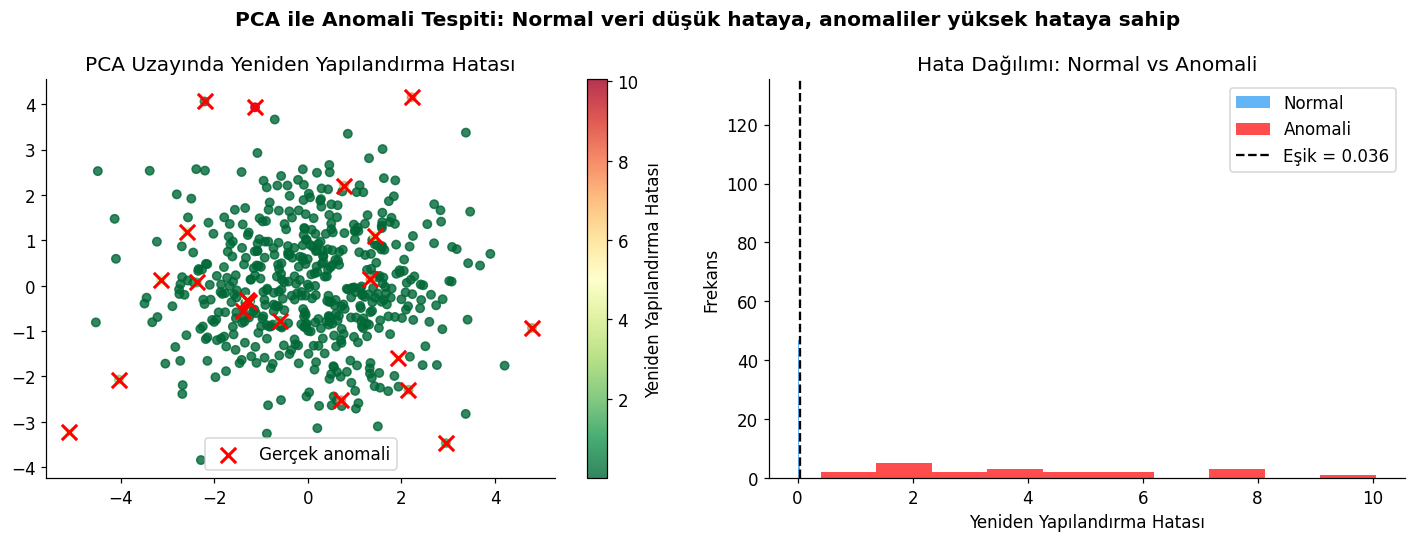

20 gerçek anomaliden tespit edilen: 20 (100%)


In [18]:
np.random.seed(7)
# Normal veri: 5 boyutlu, düşük boyutlu bir alt uzayda
X_base = np.random.randn(500, 2) @ np.random.randn(2, 5)
X_base += np.random.randn(*X_base.shape) * 0.1
# Anomaliler: rastgele 5B noktalar
X_anom_pca = np.random.randn(20, 5) * 3
X_pca_all  = np.vstack([X_base, X_anom_pca])
scaler     = StandardScaler()
X_scaled   = scaler.fit_transform(X_pca_all)

pca = PCA(n_components=2)
X_reduced   = pca.fit_transform(X_scaled)
X_reconstructed = pca.inverse_transform(X_reduced)
recon_errors = np.mean((X_scaled - X_reconstructed) ** 2, axis=1)

threshold_pca = np.percentile(recon_errors[:500], 97)
detected_pca  = recon_errors > threshold_pca

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sc2 = axes[0].scatter(X_reduced[:, 0], X_reduced[:, 1],
                      c=recon_errors, cmap="RdYlGn_r", s=30, alpha=0.8)
axes[0].scatter(X_reduced[500:, 0], X_reduced[500:, 1],
                c="red", marker="x", s=100, linewidths=2, zorder=5, label="Gerçek anomali")
plt.colorbar(sc2, ax=axes[0], label="Yeniden Yapılandırma Hatası")
axes[0].set_title("PCA Uzayında Yeniden Yapılandırma Hatası")
axes[0].legend()

axes[1].hist(recon_errors[:500], bins=30, color=PALETTE[0], alpha=0.7, label="Normal")
axes[1].hist(recon_errors[500:], bins=10, color="red", alpha=0.7, label="Anomali")
axes[1].axvline(threshold_pca, color="black", linestyle="--",
                label=f"Eşik = {threshold_pca:.3f}")
axes[1].set_xlabel("Yeniden Yapılandırma Hatası"); axes[1].set_ylabel("Frekans")
axes[1].set_title("Hata Dağılımı: Normal vs Anomali"); axes[1].legend()

plt.suptitle("PCA ile Anomali Tespiti: Normal veri düşük hataya, anomaliler yüksek hataya sahip",
             fontweight="bold")
plt.tight_layout()
plt.show()

detected_anomalies = np.sum(detected_pca[500:])
print(f"20 gerçek anomaliden tespit edilen: {detected_anomalies} ({detected_anomalies/20*100:.0f}%)")


---
## 7. Algoritma Karşılaştırması

Farklı veri tiplerinde üç kümeleme algoritmasını karşılaştırıyoruz.

| Algoritma | K gerekli? | Keyfi şekil | Gürültü toleransı | Zaman karmaşıklığı |
|-----------|-----------|-------------|-------------------|-------------------|
| K-Means   | ✅ | ❌ | Düşük | O(IKmn) |
| Hiyerarşik| ❌ | Kısmen | Orta | O(m² log m) |
| DBSCAN    | ❌ | ✅ | Yüksek | O(m log m)* |


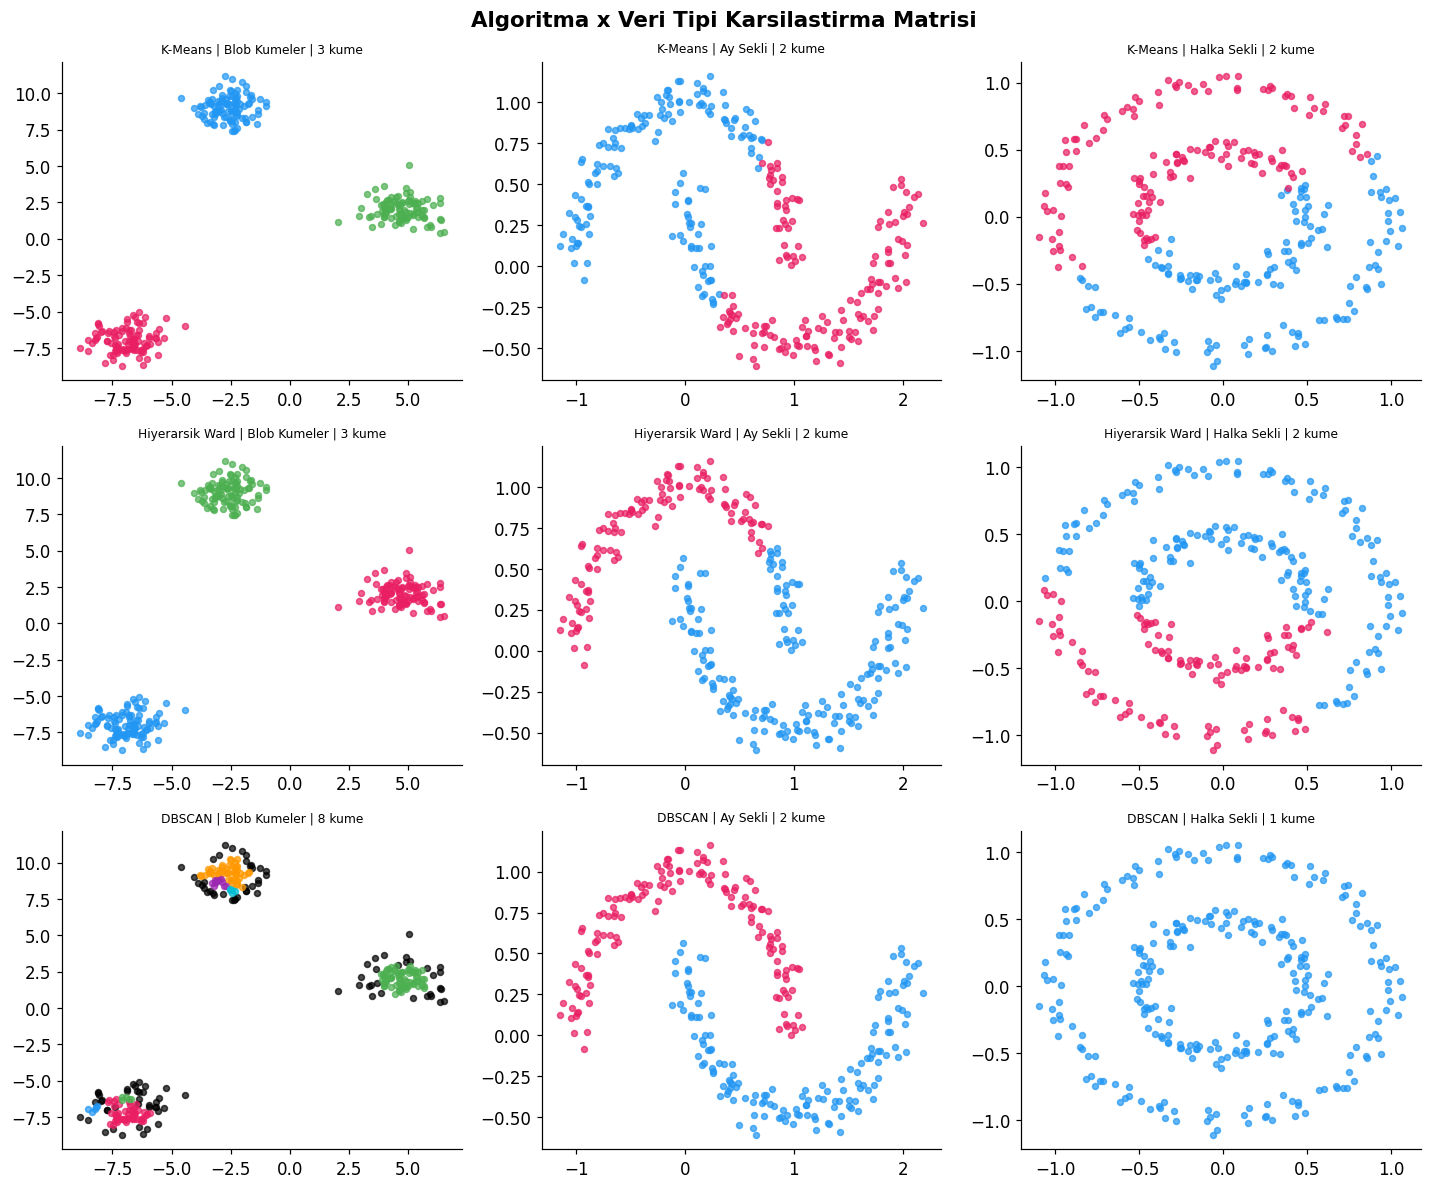

In [19]:
datasets_compare = {
    "Blob Kumeler": make_blobs(n_samples=300, centers=3, cluster_std=0.8, random_state=42),
    "Ay Sekli"    : make_moons(n_samples=300, noise=0.07, random_state=42),
    "Halka Sekli" : make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42),
}

def km_fn(X, n):
    return KMeans(n_clusters=n, n_init=10, random_state=42).fit_predict(X)
def hier_fn(X, n):
    return AgglomerativeClustering(n_clusters=n).fit_predict(X)
def db_fn(X):
    return DBSCAN(eps=0.3, min_samples=5).fit_predict(X)

fig, axes = plt.subplots(3, 3, figsize=(13, 11))

for col, (name, (X_c, _)) in enumerate(datasets_compare.items()):
    n_cl_target = 3 if "Blob" in name else 2
    alg_results = [
        ("K-Means",         km_fn(X_c, n_cl_target)),
        ("Hiyerarsik Ward", hier_fn(X_c, n_cl_target)),
        ("DBSCAN",          db_fn(X_c)),
    ]
    for row, (alg_name, lbl) in enumerate(alg_results):
        ax = axes[row][col]
        unique = sorted(set(lbl))
        for i, k in enumerate(unique):
            mask = lbl == k
            color = "black" if k == -1 else PALETTE[i % len(PALETTE)]
            ax.scatter(X_c[mask, 0], X_c[mask, 1], c=color, s=15, alpha=0.7)
        n_found = len(unique) - (1 if -1 in unique else 0)
        ax.set_title("{} | {} | {} kume".format(alg_name, name, n_found), fontsize=8)

plt.suptitle("Algoritma x Veri Tipi Karsilastirma Matrisi", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 8. Özet ve Pratik Algoritma Seçim Rehberi

| Senaryo | Önerilen Algoritma |
|---------|-------------------|
| Büyük veri, küresel kümeler | **K-Means** veya **K-Means++** |
| Hiyerarşik yapıyı keşfetmek | **Ward** veya **Complete Link** |
| Keyfi şekil, gürültülü veri | **DBSCAN** (veya HDBSCAN değişken yoğunluk için) |
| Başlangıç hassasiyetini azaltmak | **Bisecting K-Means** |
| Değerlendirme | **Silhouette skoru** + dendrogram görselleştirme |
| Anomali tespiti (dağılım biliniyorsa) | **z-skoru / Mahalanobis** |
| Anomali tespiti (yerel yoğunluk) | **LOF** |
| Anomali tespiti (boyut indirgeme) | **PCA yeniden yapılandırma** |

### Anahtar Prensipler

1. **Küme tanımı veriye ve hedefe bağlıdır** — evrensel bir "doğru küme" yoktur.
2. **Farklı algoritmalar farklı küme tiplerini varsayar** — önce veriyi tanıyın.
3. **Değerlendirme zorunludur** — SSE tek başına yeterli değildir; Silhouette kullanın.
4. **Anomali ≠ gürültü** — amaç her zaman silmek değil, tespit etmektir.
5. **Parametre seçimi kritiktir** — K, ε, MinPts kör denenmez; yöntemli seçilir.


In [20]:
print("=" * 55)
print("  Veri Madenciliği 5. Ders Notebook'u Tamamlandı!  ")
print("=" * 55)
print()
print("Kapsanan Konular:")
konular = [
    "1. Kümelemeye Giriş",
    "2. K-Means: Algoritma, K-Means++, Dirsek, Silhouette",
    "3. Hiyerarşik Kümeleme: 4 yöntem + Dendrogram",
    "4. DBSCAN: Parametre seçimi, k-dist grafiği",
    "5. Küme Değerlendirmesi: Purity, Entropi",
    "6. Anomali Tespiti: z-skoru, Mahalanobis, LOF, PCA",
    "7. Algoritma Karşılaştırma Matrisi",
]
for k in konular:
    print(f"  ✅ {k}")


  Veri Madenciliği 5. Ders Notebook'u Tamamlandı!  

Kapsanan Konular:
  ✅ 1. Kümelemeye Giriş
  ✅ 2. K-Means: Algoritma, K-Means++, Dirsek, Silhouette
  ✅ 3. Hiyerarşik Kümeleme: 4 yöntem + Dendrogram
  ✅ 4. DBSCAN: Parametre seçimi, k-dist grafiği
  ✅ 5. Küme Değerlendirmesi: Purity, Entropi
  ✅ 6. Anomali Tespiti: z-skoru, Mahalanobis, LOF, PCA
  ✅ 7. Algoritma Karşılaştırma Matrisi
